/var/folders/9d/lzf8kc5d3ksc7cxghyhwb76c0000gn/T/ipykernel_34890/2950999078.py:47: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for c in contour[0].collections:


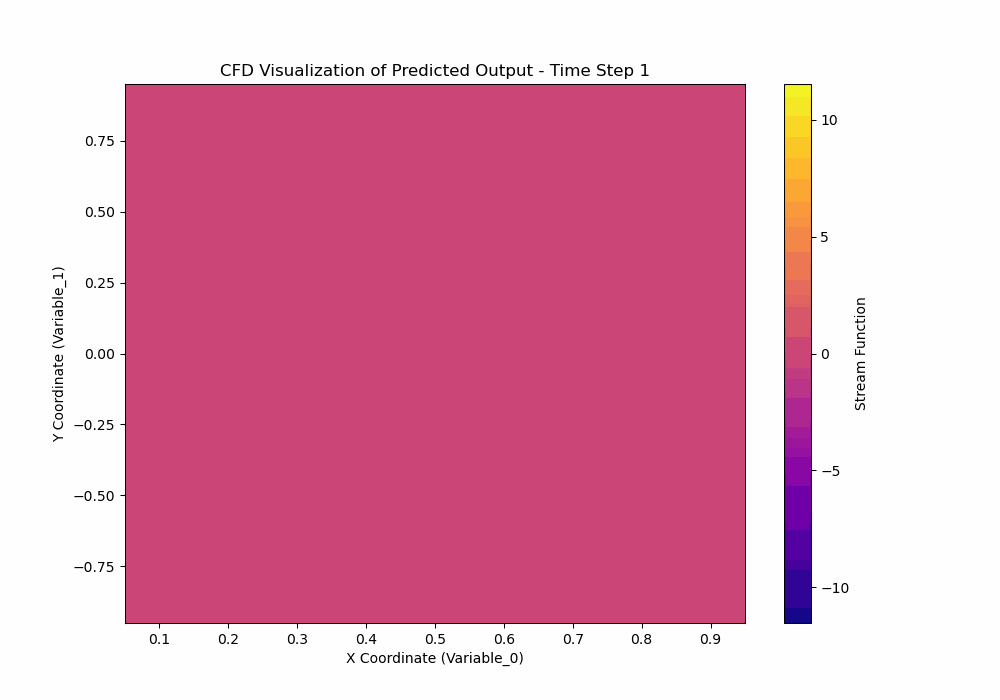

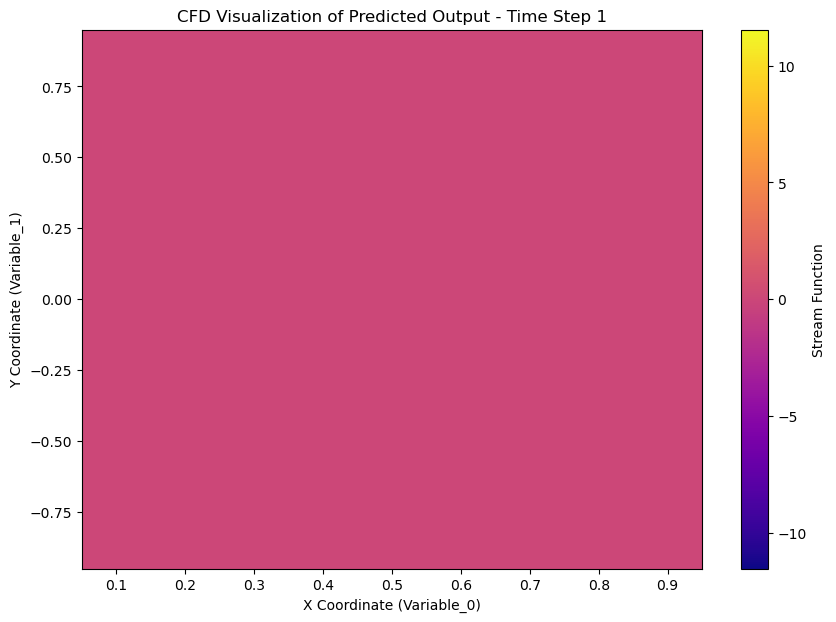

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

path = os.getcwd()

# Load the data
points_df = pd.read_csv('problems/QGE/openfoam_data/input_xyt.csv')
predicted_output_df = pd.read_csv('problems/QGE/openfoam_data/q_si.csv')

predicted_output_df_psi = predicted_output_df.iloc[:, 1]

# Merge the dataframes if they are aligned by index
df = pd.concat([points_df, predicted_output_df_psi], axis=1)
df.columns = ['x', 'y', 't', 'psi']

# Number of time steps (assuming 101 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps

# Compute global min and max for psi
vmin = df['psi'].min()
vmax = df['psi'].max()

# Set up the figure and axis for the animation
fig, ax = plt.subplots(figsize=(10, 7))

# Create contour plot for the first frame with consistent color scaling
start_idx = 0
end_idx = num_points_per_step 
contour = [ax.tricontourf(df['x'][start_idx:end_idx], 
                          df['y'][start_idx:end_idx], 
                          df['psi'][start_idx:end_idx], 
                          levels=100, cmap='plasma', vmin=vmin, vmax=vmax)]

# Add the color bar once, outside the update function
norm = Normalize(vmin=vmin, vmax=vmax)
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap='plasma'), ax=ax)
cbar.set_label('Stream Function')

# Function to update each frame
def update(frame):
    # Remove the previous contour plot
    for c in contour[0].collections:
        c.remove()
    
    start_idx = frame * num_points_per_step
    end_idx = (frame + 1) * num_points_per_step

    # Replot the contour with the new data, same vmin and vmax
    contour[0] = ax.tricontourf(df['x'][start_idx:end_idx], 
                                df['y'][start_idx:end_idx], 
                                df['psi'][start_idx:end_idx], 
                                levels=100, cmap='plasma', vmin=vmin, vmax=vmax)
    
    ax.set_title(f'CFD Visualization of Predicted Output - Time Step {frame+1}')
    ax.set_xlabel('X Coordinate (Variable_0)')
    ax.set_ylabel('Y Coordinate (Variable_1)')

# Create animation using FuncAnimation
anim = FuncAnimation(fig, update, frames=num_time_steps, repeat=False)

# Save the animation as a GIF
gif_path = os.path.join(path, 'qge_results/openfoam_cfd_result.gif')
anim.save(gif_path, writer='pillow', fps=8)

# Display the GIF in Jupyter (or other environments)
from IPython.display import Image as IPImage
IPImage(filename=gif_path)


/var/folders/9d/lzf8kc5d3ksc7cxghyhwb76c0000gn/T/ipykernel_34890/1530242703.py:45: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for c in contour[0].collections:


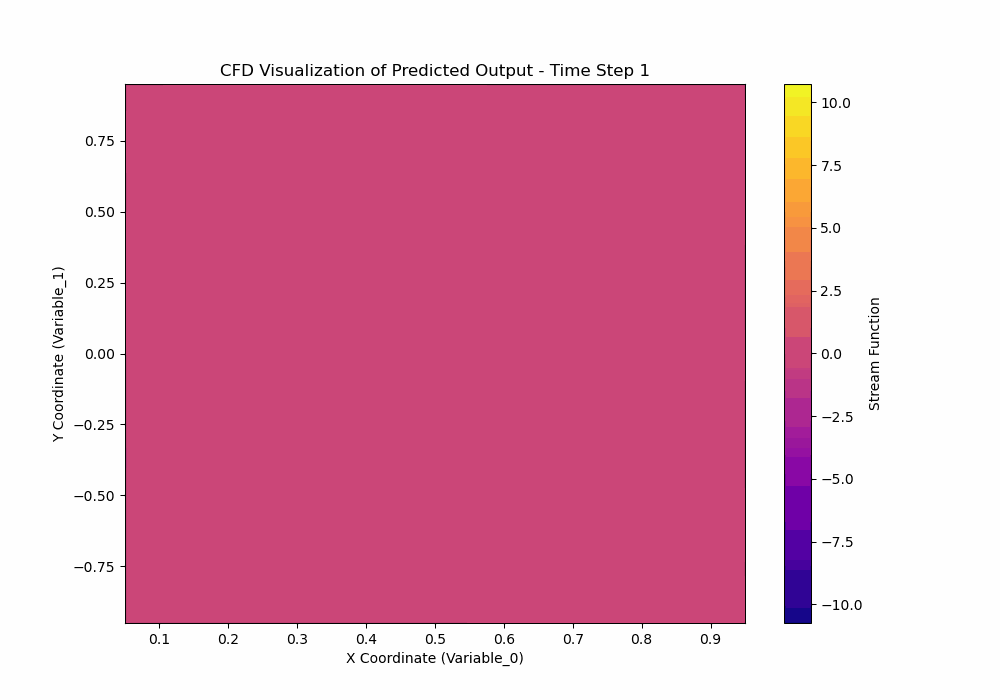

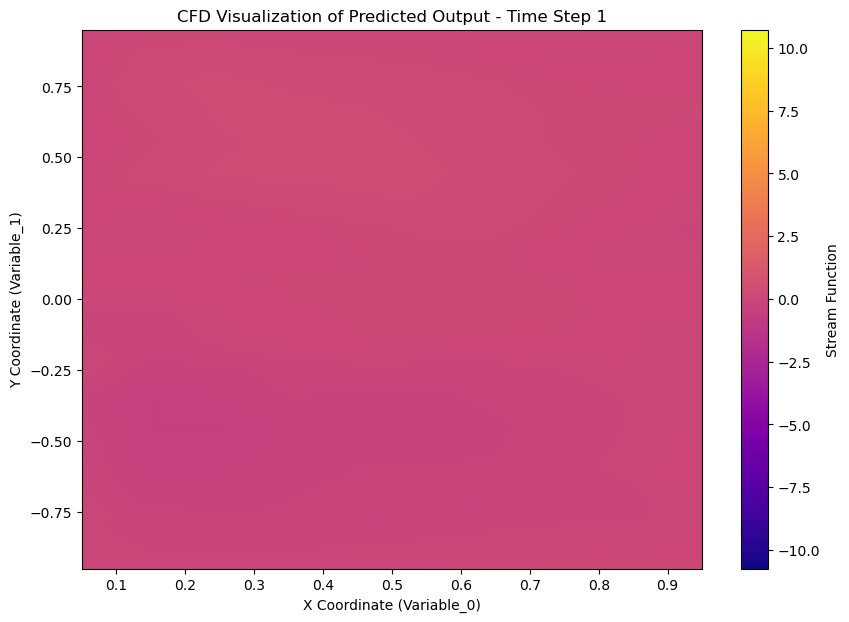

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

path = os.getcwd()

# Load the data
points_df = pd.read_csv('problems/QGE/plotting/points.csv')
predicted_output_df = pd.read_csv('problems/QGE/plotting/predicted_output.csv')

# Merge the dataframes if they are aligned by index
df = pd.concat([points_df, predicted_output_df], axis=1)
df.columns = ['x', 'y', 't', 'psi']

# Number of time steps (assuming 101 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps

# Compute global min and max for psi
vmin = df['psi'].min()
vmax = df['psi'].max()

# Set up the figure and axis for the animation
fig, ax = plt.subplots(figsize=(10, 7))

# Create contour plot for the first frame with consistent color scaling
start_idx = 0
end_idx = num_points_per_step 
contour = [ax.tricontourf(df['x'][start_idx:end_idx], 
                          df['y'][start_idx:end_idx], 
                          df['psi'][start_idx:end_idx], 
                          levels=100, cmap='plasma', vmin=vmin, vmax=vmax)]

# Add the color bar once, outside the update function
norm = Normalize(vmin=vmin, vmax=vmax)
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap='plasma'), ax=ax)
cbar.set_label('Stream Function')

# Function to update each frame
def update(frame):
    # Remove the previous contour plot
    for c in contour[0].collections:
        c.remove()
    
    start_idx = frame * num_points_per_step
    end_idx = (frame + 1) * num_points_per_step

    # Replot the contour with the new data, same vmin and vmax
    contour[0] = ax.tricontourf(df['x'][start_idx:end_idx], 
                                df['y'][start_idx:end_idx], 
                                df['psi'][start_idx:end_idx], 
                                levels=100, cmap='plasma', vmin=vmin, vmax=vmax)
    
    ax.set_title(f'CFD Visualization of Predicted Output - Time Step {frame+1}')
    ax.set_xlabel('X Coordinate (Variable_0)')
    ax.set_ylabel('Y Coordinate (Variable_1)')

# Create animation using FuncAnimation
anim = FuncAnimation(fig, update, frames=num_time_steps, repeat=False)

# Save the animation as a GIF
gif_path = os.path.join(path, 'qge_results/pinn_cfd_result.gif')
anim.save(gif_path, writer='pillow', fps=8)

# Display the GIF in Jupyter (or other environments)
from IPython.display import Image as IPImage
IPImage(filename=gif_path)


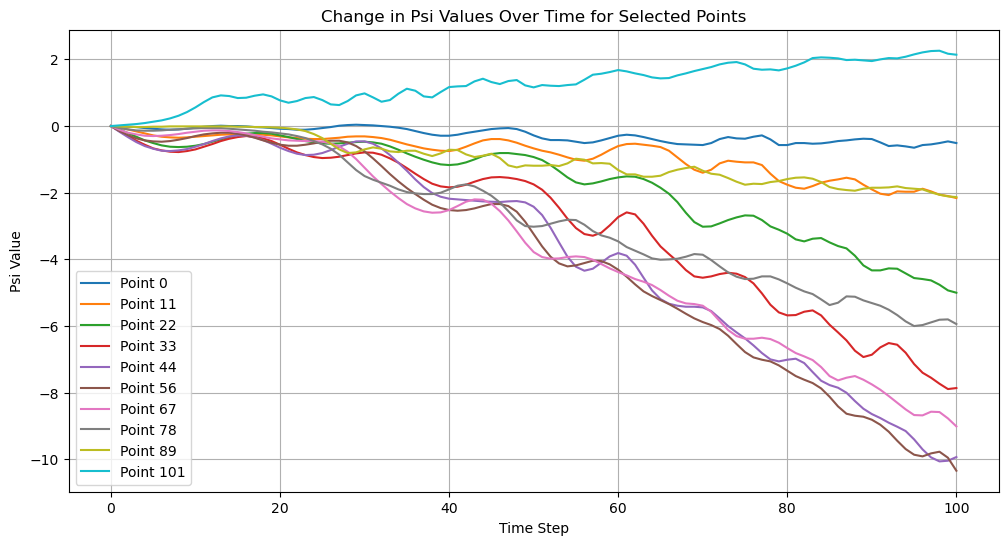

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
points_df = pd.read_csv('problems/QGE/openfoam_data/input_xyt.csv')
predicted_output_df = pd.read_csv('problems/QGE/openfoam_data/q_si.csv')
predicted_output_df_psi = predicted_output_df.iloc[:, 1]  # Assuming psi values are in the second column

# Merge the dataframes
df = pd.concat([points_df, predicted_output_df_psi.rename('psi')], axis=1)

# Number of time steps (assuming 100 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps


# Choose 10 points to track across time steps (e.g., points 0, 1, 2, ..., 9)
# selected_points = list(range(10))
selected_points = np.linspace(0, 101, 10, dtype='int64').tolist()

# Initialize lists to store psi values over time for each selected point
psi_values_over_time = {point: [] for point in selected_points}

# Loop through each time step and extract psi values for the selected points
for t in range(num_time_steps):
    start_idx = t * num_points_per_step
    end_idx = (t + 1) * num_points_per_step
    time_step_df = df[start_idx:end_idx]

    for point in selected_points:
        psi_values_over_time[point].append(time_step_df['psi'].iloc[point])

# Plot the change in psi values over time for each selected point
plt.figure(figsize=(12, 6))
for point, psi_values in psi_values_over_time.items():
    plt.plot(range(num_time_steps), psi_values, label=f'Point {point}')
plt.title('Change in Psi Values Over Time for Selected Points')
plt.xlabel('Time Step')
plt.ylabel('Psi Value')
plt.legend()
plt.grid(True)
plt.show()


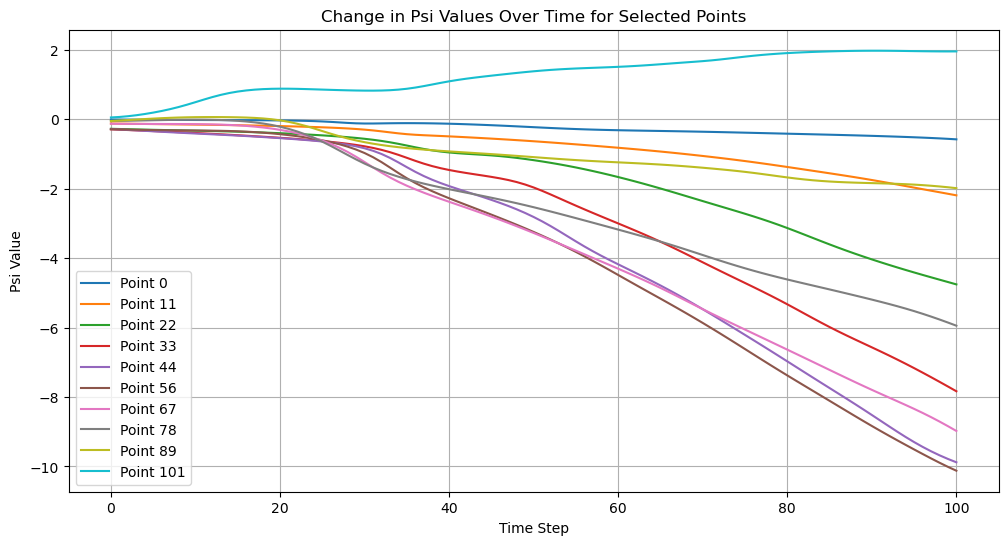

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
points_df = pd.read_csv('problems/QGE/plotting/points.csv')
predicted_output_df = pd.read_csv('problems/QGE/plotting/predicted_output.csv')

# Merge the dataframes
df = pd.concat([points_df, predicted_output_df], axis=1)

# Number of time steps (assuming 25 time steps)
num_time_steps = 101
num_points_per_step = len(df) // num_time_steps

# Initialize lists to store psi values over time for each selected point
psi_values_over_time = {point: [] for point in selected_points}

# Loop through each time step and extract psi values for the selected points
for t in range(num_time_steps):
    start_idx = t * num_points_per_step
    end_idx = (t + 1) * num_points_per_step
    time_step_df = df[start_idx:end_idx]

    for point in selected_points:
        psi_values_over_time[point].append(time_step_df['Prediction'].iloc[point])

# Plot the change in psi values over time for each selected point
plt.figure(figsize=(12, 6))
for point, psi_values in psi_values_over_time.items():
    plt.plot(range(num_time_steps), psi_values, label=f'Point {point}')
plt.title('Change in Psi Values Over Time for Selected Points')
plt.xlabel('Time Step')
plt.ylabel('Psi Value')
plt.legend()
plt.grid(True)
plt.show()


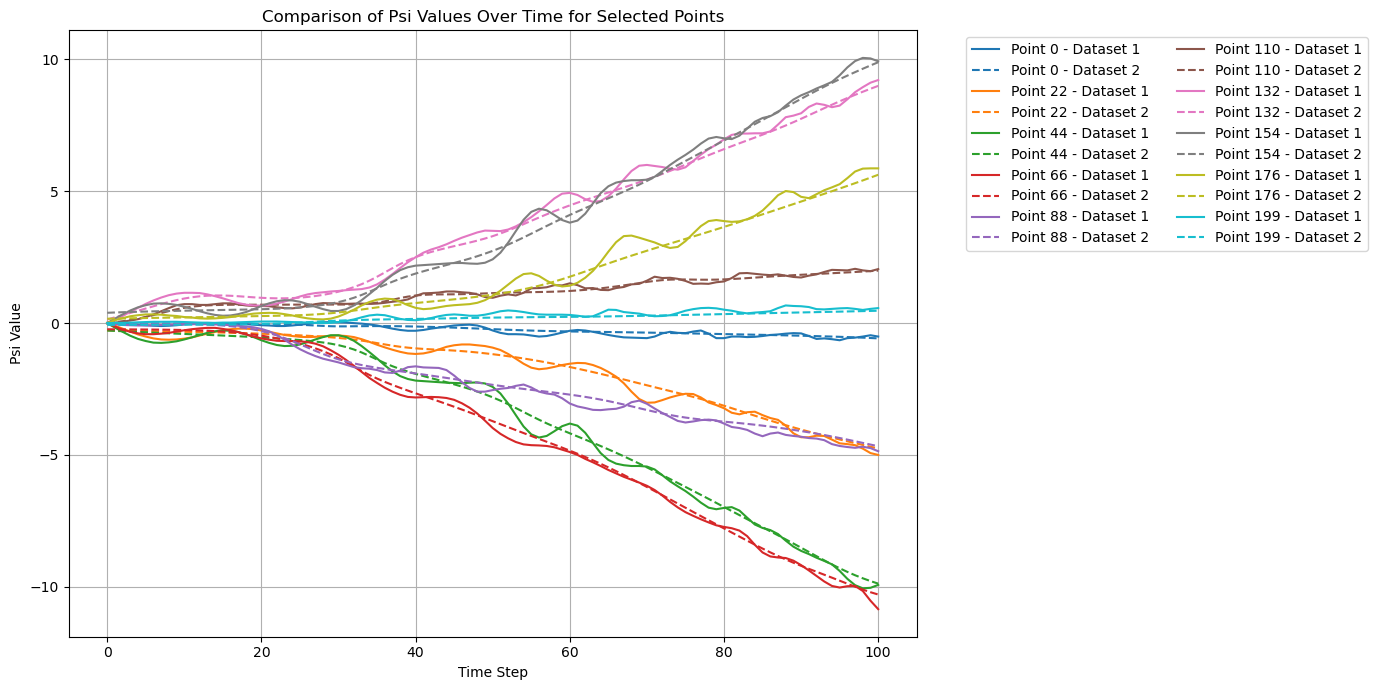

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the first dataset
points_df1 = pd.read_csv('problems/QGE/openfoam_data/input_xyt.csv')
predicted_output_df1 = pd.read_csv('problems/QGE/openfoam_data/q_si.csv')
predicted_output_df1_psi = predicted_output_df1.iloc[:, 1]  # Assuming psi values are in the second column

# Merge the dataframes
df1 = pd.concat([points_df1, predicted_output_df1_psi.rename('psi')], axis=1)
df1.columns = ['x', 'y', 't', 'psi']

# Load the second dataset
points_df2 = pd.read_csv('problems/QGE/plotting/points.csv')
predicted_output_df2 = pd.read_csv('problems/QGE/plotting/predicted_output.csv')

# Merge the dataframes
df2 = pd.concat([points_df2, predicted_output_df2.rename(columns={'Prediction': 'psi'})], axis=1)
df2.columns = ['x', 'y', 't', 'psi']

# Ensure that both datasets have the same number of time steps and points per step
num_time_steps = 101  # Adjust if necessary
num_points_per_step = len(df1) // num_time_steps

# Choose selected points to track across time steps (e.g., equally spaced points)
selected_points = np.linspace(0, num_points_per_step - 1, 10, dtype='int64').tolist() 

# Initialize dictionaries to store psi values over time for each selected point from both datasets
psi_values_over_time1 = {point: [] for point in selected_points}
psi_values_over_time2 = {point: [] for point in selected_points}

# Loop through each time step and extract psi values for the selected points from both datasets
for t in range(num_time_steps):
    start_idx = t * num_points_per_step
    end_idx = (t + 1) * num_points_per_step
    
    # Extract data for the current time step
    time_step_df1 = df1.iloc[start_idx:end_idx].reset_index(drop=True)
    time_step_df2 = df2.iloc[start_idx:end_idx].reset_index(drop=True)
    
    for point in selected_points:
        # Get psi value for the current point from both datasets
        psi1 = time_step_df1['psi'].iloc[point]
        psi2 = time_step_df2['psi'].iloc[point]
        
        psi_values_over_time1[point].append(psi1)
        psi_values_over_time2[point].append(psi2)

# Prepare colors for each point
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_points)))

# Plot the change in psi values over time for each selected point
plt.figure(figsize=(14, 7))

for idx, point in enumerate(selected_points):
    plt.plot(range(num_time_steps), psi_values_over_time1[point], label=f'Point {point} - Dataset 1', linestyle='-', color=colors[idx])
    plt.plot(range(num_time_steps), psi_values_over_time2[point], label=f'Point {point} - Dataset 2', linestyle='--', color=colors[idx])

plt.title('Comparison of Psi Values Over Time for Selected Points')
plt.xlabel('Time Step')
plt.ylabel('Psi Value')
plt.legend(ncol=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


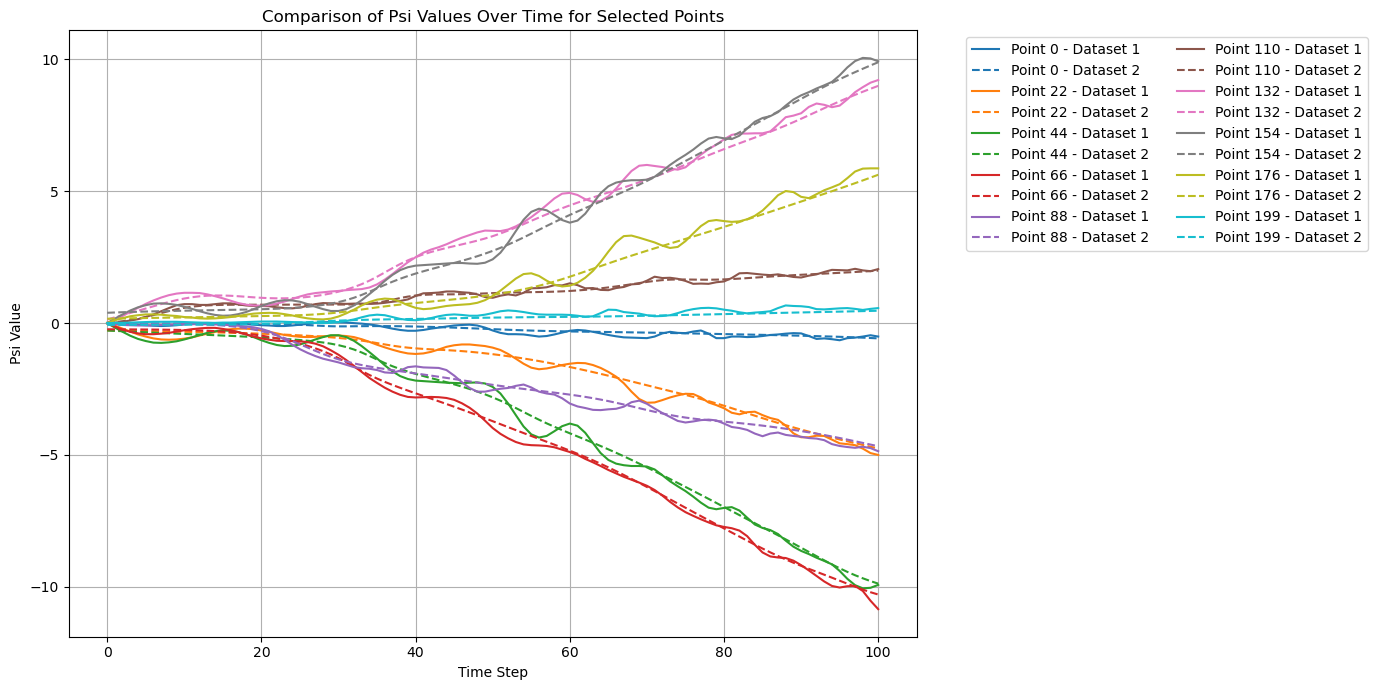

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the first dataset
points_df1 = pd.read_csv('problems/QGE/openfoam_data/input_xyt.csv')
predicted_output_df1 = pd.read_csv('problems/QGE/openfoam_data/q_si.csv')
predicted_output_df1_psi = predicted_output_df1.iloc[:, 1]  # Assuming psi values are in the second column

# Merge the dataframes
df1 = pd.concat([points_df1, predicted_output_df1_psi.rename('psi')], axis=1)
df1.columns = ['x', 'y', 't', 'psi']

# Load the second dataset
points_df2 = pd.read_csv('problems/QGE/plotting/points.csv')
predicted_output_df2 = pd.read_csv('problems/QGE/plotting/predicted_output.csv')

# Merge the dataframes
df2 = pd.concat([points_df2, predicted_output_df2.rename(columns={'Prediction': 'psi'})], axis=1)
df2.columns = ['x', 'y', 't', 'psi']

# Ensure that both datasets have the same number of time steps and points per step
num_time_steps = 101  # Adjust if necessary
num_points_per_step = len(df1) // num_time_steps

# Choose selected points to track across time steps (e.g., equally spaced points)
selected_points = np.linspace(0, num_points_per_step - 1, 10, dtype='int64').tolist()

# Initialize dictionaries to store psi values over time for each selected point from both datasets
psi_values_over_time1 = {point: [] for point in selected_points}
psi_values_over_time2 = {point: [] for point in selected_points}

# Loop through each time step and extract psi values for the selected points from both datasets
for t in range(num_time_steps):
    start_idx = t * num_points_per_step
    end_idx = (t + 1) * num_points_per_step
    
    # Extract data for the current time step
    time_step_df1 = df1.iloc[start_idx:end_idx].reset_index(drop=True)
    time_step_df2 = df2.iloc[start_idx:end_idx].reset_index(drop=True)
    
    for point in selected_points:
        # Get psi value for the current point from both datasets
        psi1 = time_step_df1['psi'].iloc[point]
        psi2 = time_step_df2['psi'].iloc[point]
        
        psi_values_over_time1[point].append(psi1)
        psi_values_over_time2[point].append(psi2)

# Prepare colors for each point
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_points)))

# Plot the change in psi values over time for each selected point
plt.figure(figsize=(14, 7))

for idx, point in enumerate(selected_points):
    plt.plot(range(num_time_steps), psi_values_over_time1[point], label=f'Point {point} - Dataset 1', linestyle='-', color=colors[idx])
    plt.plot(range(num_time_steps), psi_values_over_time2[point], label=f'Point {point} - Dataset 2', linestyle='--', color=colors[idx])

plt.title('Comparison of Psi Values Over Time for Selected Points')
plt.xlabel('Time Step')
plt.ylabel('Psi Value')
plt.legend(ncol=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Save the plot to a file
plt.savefig('qge_results/pointwise_comparison_plot.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()
